In [1]:
import numpy as np

rng = np.random.default_rng(0)

In [2]:
''' Возьмем простые данные - n-мерное изотропное нормальное распределение N(0, I_d) '''

# Базовая цель (N(0, I))
def logp(x):
    return -0.5 * np.dot(x, x)

def grad_logp(x):
    return -x

# Доп. пример данных: коррелированная гауссиана N(0, Σ) с одинаковыми корреляциями
# Σ = (1-ρ) I + ρ 1 1^T, где ρ in [0,1)
# Возвращает замыкания logp, grad_logp под выбранные d и ρ

def make_correlated_gaussian(d, rho=0.9):
    I = np.eye(d)
    J = np.ones((d, d))
    Sigma = (1 - rho) * I + rho * J
    Prec = np.linalg.inv(Sigma)  # матрица точности Σ^{-1}

    def _logp(x):
        return -0.5 * x.T @ Prec @ x

    def _grad_logp(x):
        return -Prec @ x

    return _logp, _grad_logp


def your_data_utils():
    '''
    Пример: создадим другую целевую плотность — коррелированную гауссиану.
    Использование:
        logp_alt, grad_logp_alt = make_correlated_gaussian(d=10, rho=0.9)
        # затем можно переопределить глобальные logp/grad_logp на эти функции и прогнать цепи
    '''
    return make_correlated_gaussian

In [3]:
''' Посчитаем ESS через интегрированную автокорреляции '''

def ess(x):
    x = x - x.mean()

    acf = np.correlate(x, x, mode='full')
    acf = acf[len(acf) // 2:]
    acf /= acf[0]

    tau = 1 + 2 * np.sum(acf[1:200])

    return len(x) / tau

In [4]:
''' Базовая реализация MH алгоритма '''

def mh(x0, steps, scale):
    x = x0.copy()
    d = len(x)

    chain = np.zeros((steps, d))
    accept = 0

    for t in range(steps):
        prop = x + rng.normal(0, scale, size=d)

        if np.log(rng.uniform()) < (logp(prop) - logp(x)):
            x = prop; accept += 1

        chain[t] = x

    return chain, accept / steps

In [5]:
# Тут нужно заимплементить Metropolis Adjusted Langevin Algorithm (MALA)

# Контракт:
# x0: np.ndarray начальная точка
# steps: число шагов
# step: длина шага диффузии (epsilon). Рекомендуем: порядка 0.5 / sqrt(d)
# Возвращает: цепочку shape (steps, d) и долю принятых предложений.
# Edge cases: слишком большой step -> низкий accept; слишком маленький -> сильная корреляция.

def mala(x0, steps, step):
    x = x0.copy()
    d = len(x)
    chain = np.zeros((steps, d))
    accept = 0

    for t in range(steps):
        # Предложение из аппрокс. перехода Ланжевена:
        mean_prop = x + 0.5 * step * grad_logp(x)
        prop = mean_prop + np.sqrt(step) * rng.normal(size=d)

        # Лог плотности текущей и предложенной
        logp_x = logp(x)
        logp_prop = logp(prop)

        # Коррекция асимметрии: q(x|prop) и q(prop|x)
        mean_back = prop + 0.5 * step * grad_logp(prop)
        # Гауссовы лог-правдоподобия
        log_q_forward = -0.5 * np.sum((prop - mean_prop)**2) / step
        log_q_backward = -0.5 * np.sum((x - mean_back)**2) / step

        log_alpha = (logp_prop - logp_x) + (log_q_backward - log_q_forward)
        if np.log(rng.uniform()) < log_alpha:
            x = prop
            accept += 1
        chain[t] = x

    return chain, accept / steps

In [6]:
d = 10
steps = 30000
burn = 5000
x0 = np.ones(d) * 3  # стартанем в точке 3, например

# Подбор параметров пропозалов (разумные стартовые значения)
# Для MH (Random Walk MH) оптимальный масштаб ~ 2.4/sqrt(d)
mh_scale = 2.4 / np.sqrt(d)
# Для MALA целевой accept ~ 0.57; возьмем шаг порядка d^{-1/3}
mala_step = (1.0 / d) ** (1/3)

mh_chain, mh_acc = mh(x0, steps, scale=mh_scale)
mala_chain, mala_acc = mala(x0, steps, step=mala_step)

# Выведите снизу acceptance rate и медианный ESS по размерности d для MH и MALA. Не забудьте обрезать burn-in!

def median_ess_matrix(chain, burn):
    # считаем ESS отдельно по каждой координате
    chain_eff = chain[burn:]
    ess_dims = []
    for j in range(chain_eff.shape[1]):
        ess_dims.append(ess(chain_eff[:, j]))
    ess_dims = np.array(ess_dims)
    return np.median(ess_dims), ess_dims

mh_med_ess, mh_ess_dims = median_ess_matrix(mh_chain, burn)
mala_med_ess, mala_ess_dims = median_ess_matrix(mala_chain, burn)

print(f"MH:    accept={mh_acc:.3f}, median ESS={mh_med_ess:.1f} / {steps-burn}")
print(f"MALA:  accept={mala_acc:.3f}, median ESS={mala_med_ess:.1f} / {steps-burn}")

MH:    accept=0.259, median ESS=844.2 / 25000
MALA:  accept=0.899, median ESS=3113.6 / 25000


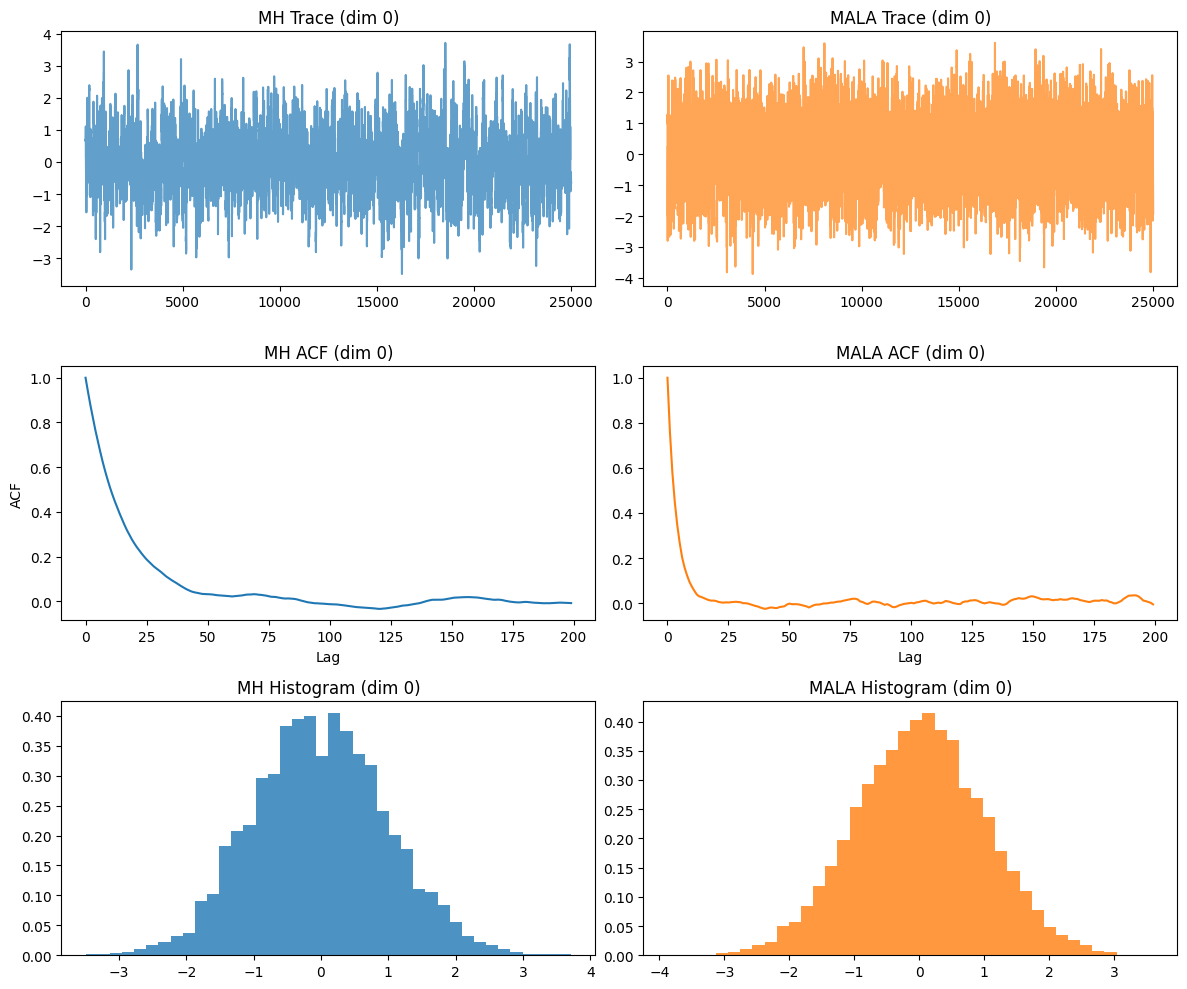

In [7]:
# Здесь нарисуйте 3 графика: trace plot (значение цепи vs итерация),
# график автокорреляции (значение ACF vs задержка по времени) и гистограмма семплов (возьмите какую-то одну размерность)

import matplotlib.pyplot as plt

plot_dim = 0  # будем смотреть на первую координату

mh_samples = mh_chain[burn:, plot_dim]
mala_samples = mala_chain[burn:, plot_dim]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Trace plots
axes[0, 0].plot(mh_samples, color='tab:blue', alpha=0.7)
axes[0, 0].set_title('MH Trace (dim 0)')
axes[0, 1].plot(mala_samples, color='tab:orange', alpha=0.7)
axes[0, 1].set_title('MALA Trace (dim 0)')

# ACF plots (простая реализация)
def acf_vals(x, max_lag=200):
    x = x - x.mean()
    acf_full = np.correlate(x, x, mode='full')
    acf_full = acf_full[len(acf_full)//2:]
    acf_full /= acf_full[0]
    return acf_full[:max_lag]

lags = np.arange(200)
axes[1, 0].plot(lags, acf_vals(mh_samples), color='tab:blue')
axes[1, 0].set_title('MH ACF (dim 0)')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('ACF')
axes[1, 1].plot(lags, acf_vals(mala_samples), color='tab:orange')
axes[1, 1].set_title('MALA ACF (dim 0)')
axes[1, 1].set_xlabel('Lag')

# Histograms
axes[2, 0].hist(mh_samples, bins=40, color='tab:blue', alpha=0.8, density=True)
axes[2, 0].set_title('MH Histogram (dim 0)')
axes[2, 1].hist(mala_samples, bins=40, color='tab:orange', alpha=0.8, density=True)
axes[2, 1].set_title('MALA Histogram (dim 0)')

plt.tight_layout()
plt.show()

In [8]:
# Тест на других данных: коррелированная гауссиана
# Переопределим цель и сравним на укороченной цепочке

make_cg = your_data_utils()  # это функция make_correlated_gaussian
logp_cg, grad_logp_cg = make_cg(d=d, rho=0.9)

# Сохраним старые цели, чтобы можно было вернуть при желании
_logp_old, _grad_old = logp, grad_logp
logp, grad_logp = logp_cg, grad_logp_cg

steps_alt = 20000
burn_alt = 4000

mh_chain_cg, mh_acc_cg = mh(x0, steps_alt, scale=mh_scale)
mala_chain_cg, mala_acc_cg = mala(x0, steps_alt, step=mala_step)

mh_med_ess_cg, _ = median_ess_matrix(mh_chain_cg, burn_alt)
mala_med_ess_cg, _ = median_ess_matrix(mala_chain_cg, burn_alt)

print('Correlated Gaussian target:')
print(f"MH:    accept={mh_acc_cg:.3f}, median ESS={mh_med_ess_cg:.1f} / {steps_alt-burn_alt}")
print(f"MALA:  accept={mala_acc_cg:.3f}, median ESS={mala_med_ess_cg:.1f} / {steps_alt-burn_alt}")

# Вернем исходные цели
logp, grad_logp = _logp_old, _grad_old

Correlated Gaussian target:
MH:    accept=0.004, median ESS=40.9 / 16000
MALA:  accept=0.003, median ESS=44.1 / 16000
